In [1]:
#### Testing whether the 2ndB self-energy calculation is correct 
import numpy as np
import WCE as wce
import _2ndB as _2ndB
import matplotlib.pyplot as plt

In [66]:
# ---------------------------
# Minimal demo scaffold
# ---------------------------
beta = 80.0
U = 1.0 
t = -4
Ns = 32
Nw = int(beta*4)
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta
Ntau = 401
tau = np.linspace(0,beta, Ntau)
G0ij_iwn, _ = wce.HF_G0(t, Ns, wn)

# Toy model: diagonal sites with different onsite energies
# Sij_iwn = _2ndB._2ndB_from_G0(G0ij_iwn, U, beta, n_vals, overall_sign=-1.0)
# Gij_iwn = _2ndB.G2(G0ij_iwn, U=U, beta=beta, n_vals=n_vals, overall_sign=-1.0)
Gij_iwn_wce = wce.Gij_wce_U(2, Ns, U, wn, beta, t)

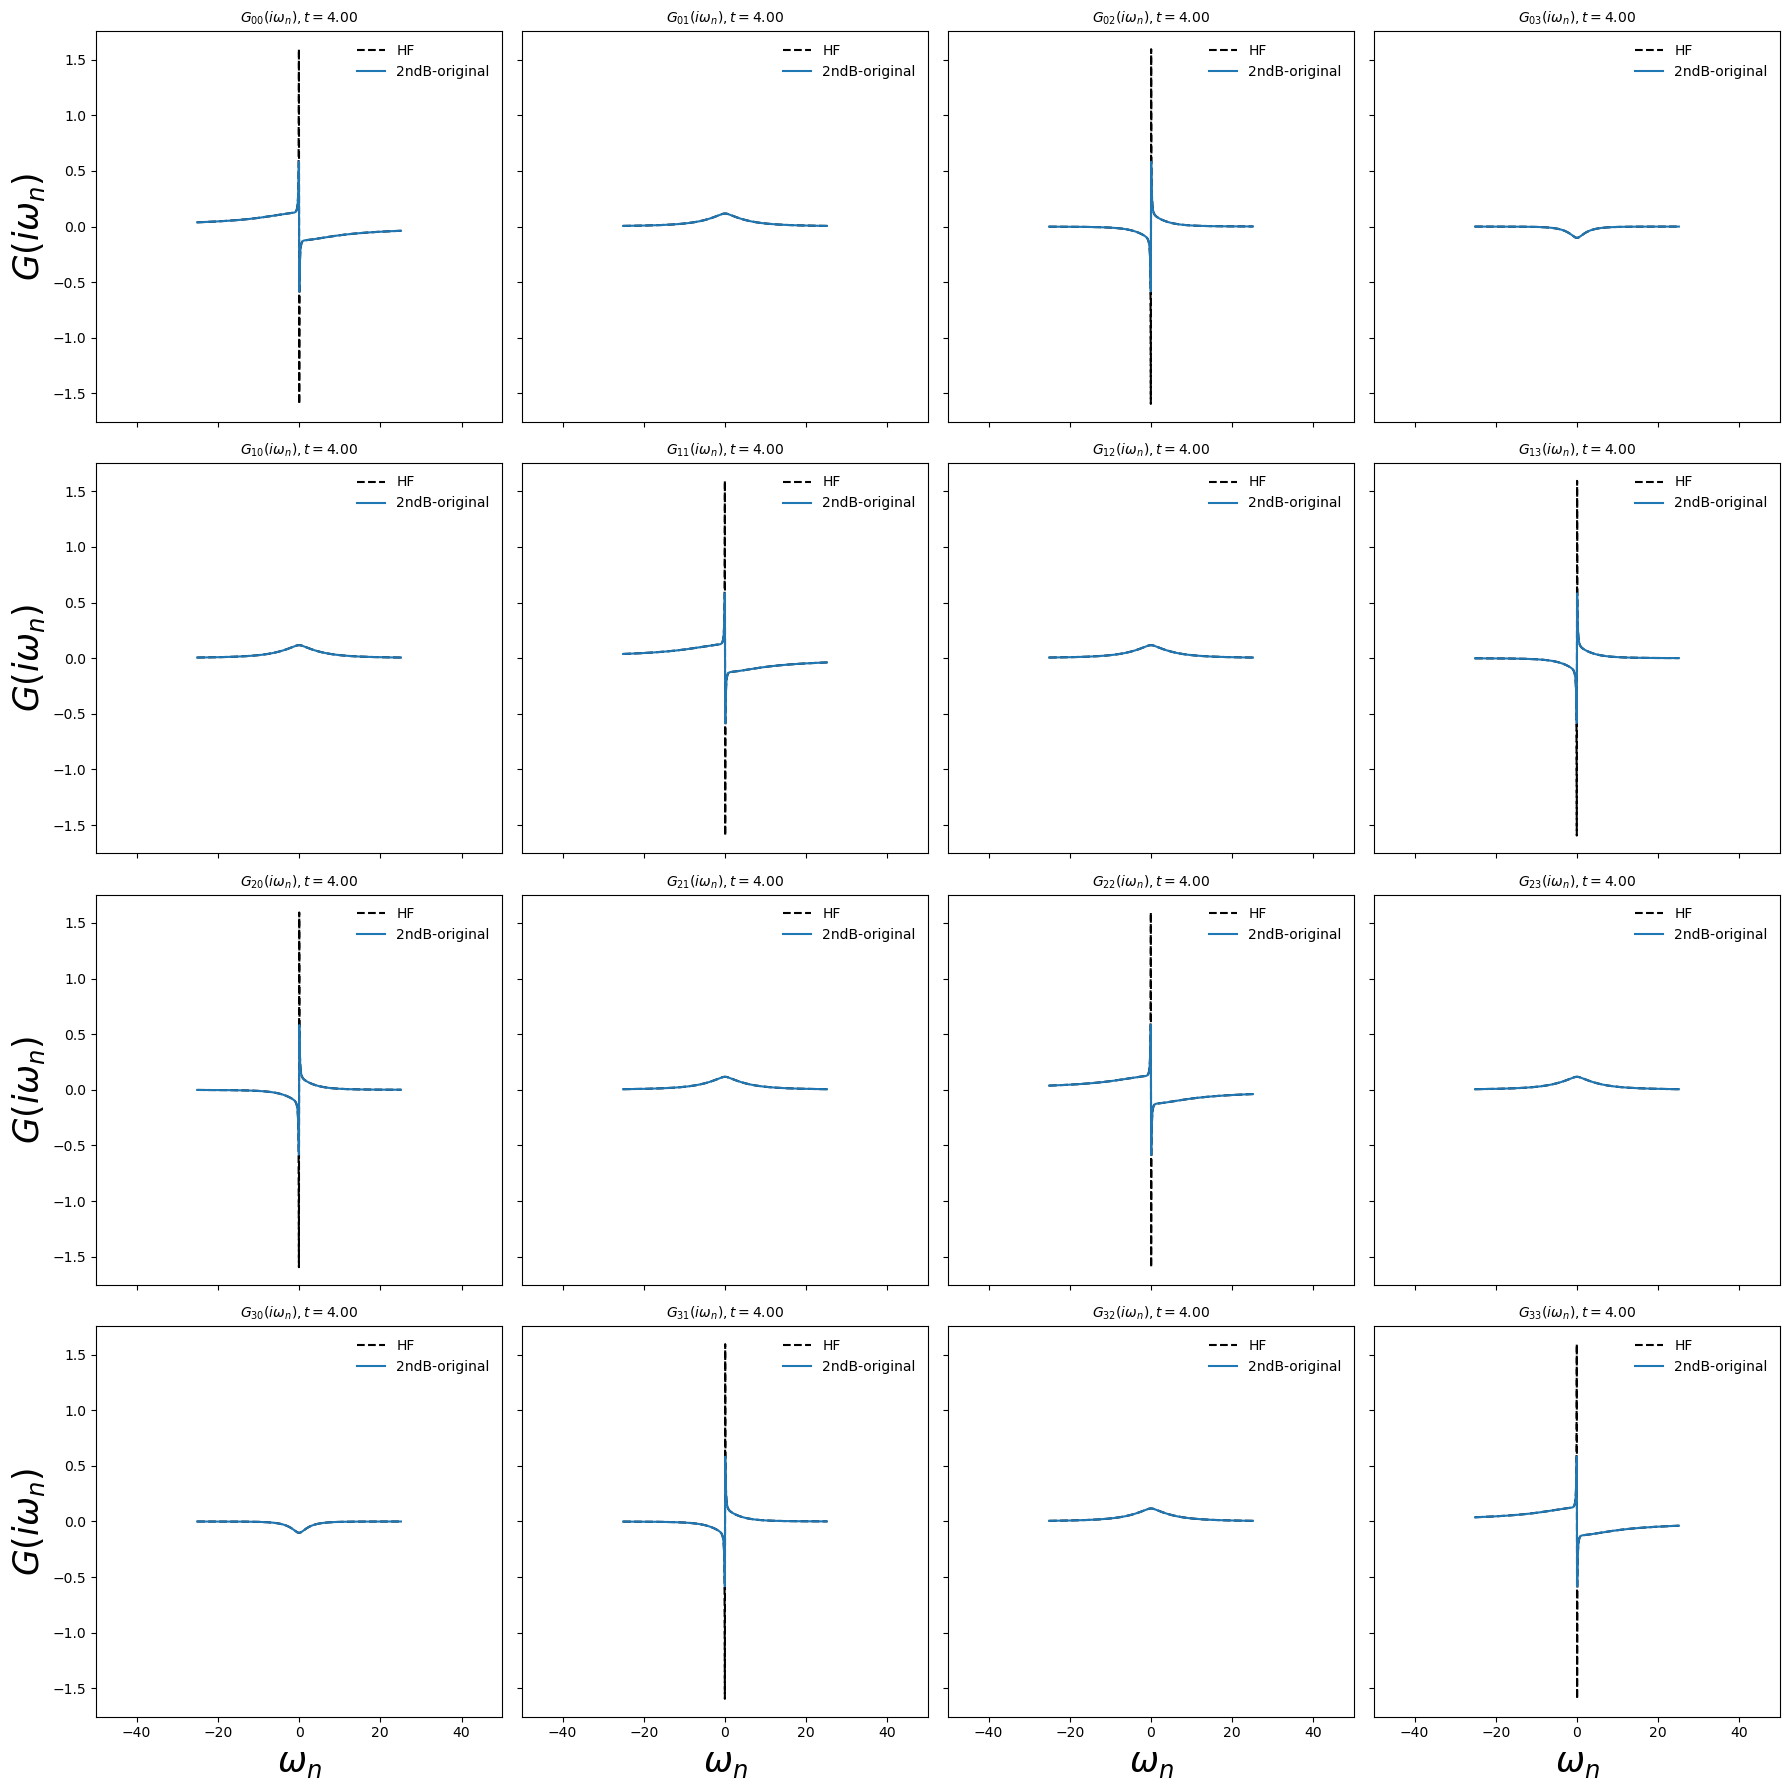

In [67]:
Ns_plot = 4
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        if (-1)**(i+j) <0:
            ax.plot(wn, G0ij_iwn[:, i ,j ].real, 'k--', label= 'HF')
            # ax.plot(wn, Gij_iwn[:, i ,j ].real, 'r', label= '2ndB')
            ax.plot(wn, Gij_iwn_wce[:, i ,j ].real, 'C0', label= '2ndB-original')
        else:
            ax.plot(wn, G0ij_iwn[:, i ,j ].imag, 'k--', label= 'HF')
            # ax.plot(wn, Gij_iwn[:, i ,j ].imag, 'r', label= '2ndB')
            ax.plot(wn, Gij_iwn_wce[:, i ,j ].imag, 'C0', label= '2ndB-original')
        ax.set_title(r'$G_{%d%d}(i\omega_n), t=%.2f$'%(i,j,-t), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend(frameon = False)
        if i == Ns_plot - 1:
            ax.set_xlabel(r"$\omega_n$", fontsize=25)
            ax.set_xlim([-50,50])
            # ax.set_ylim([-10,10])
        if j == 0:
            ax.set_ylabel(r"$G(i\omega_n)$", fontsize=25)

plt.tight_layout()
plt.show()


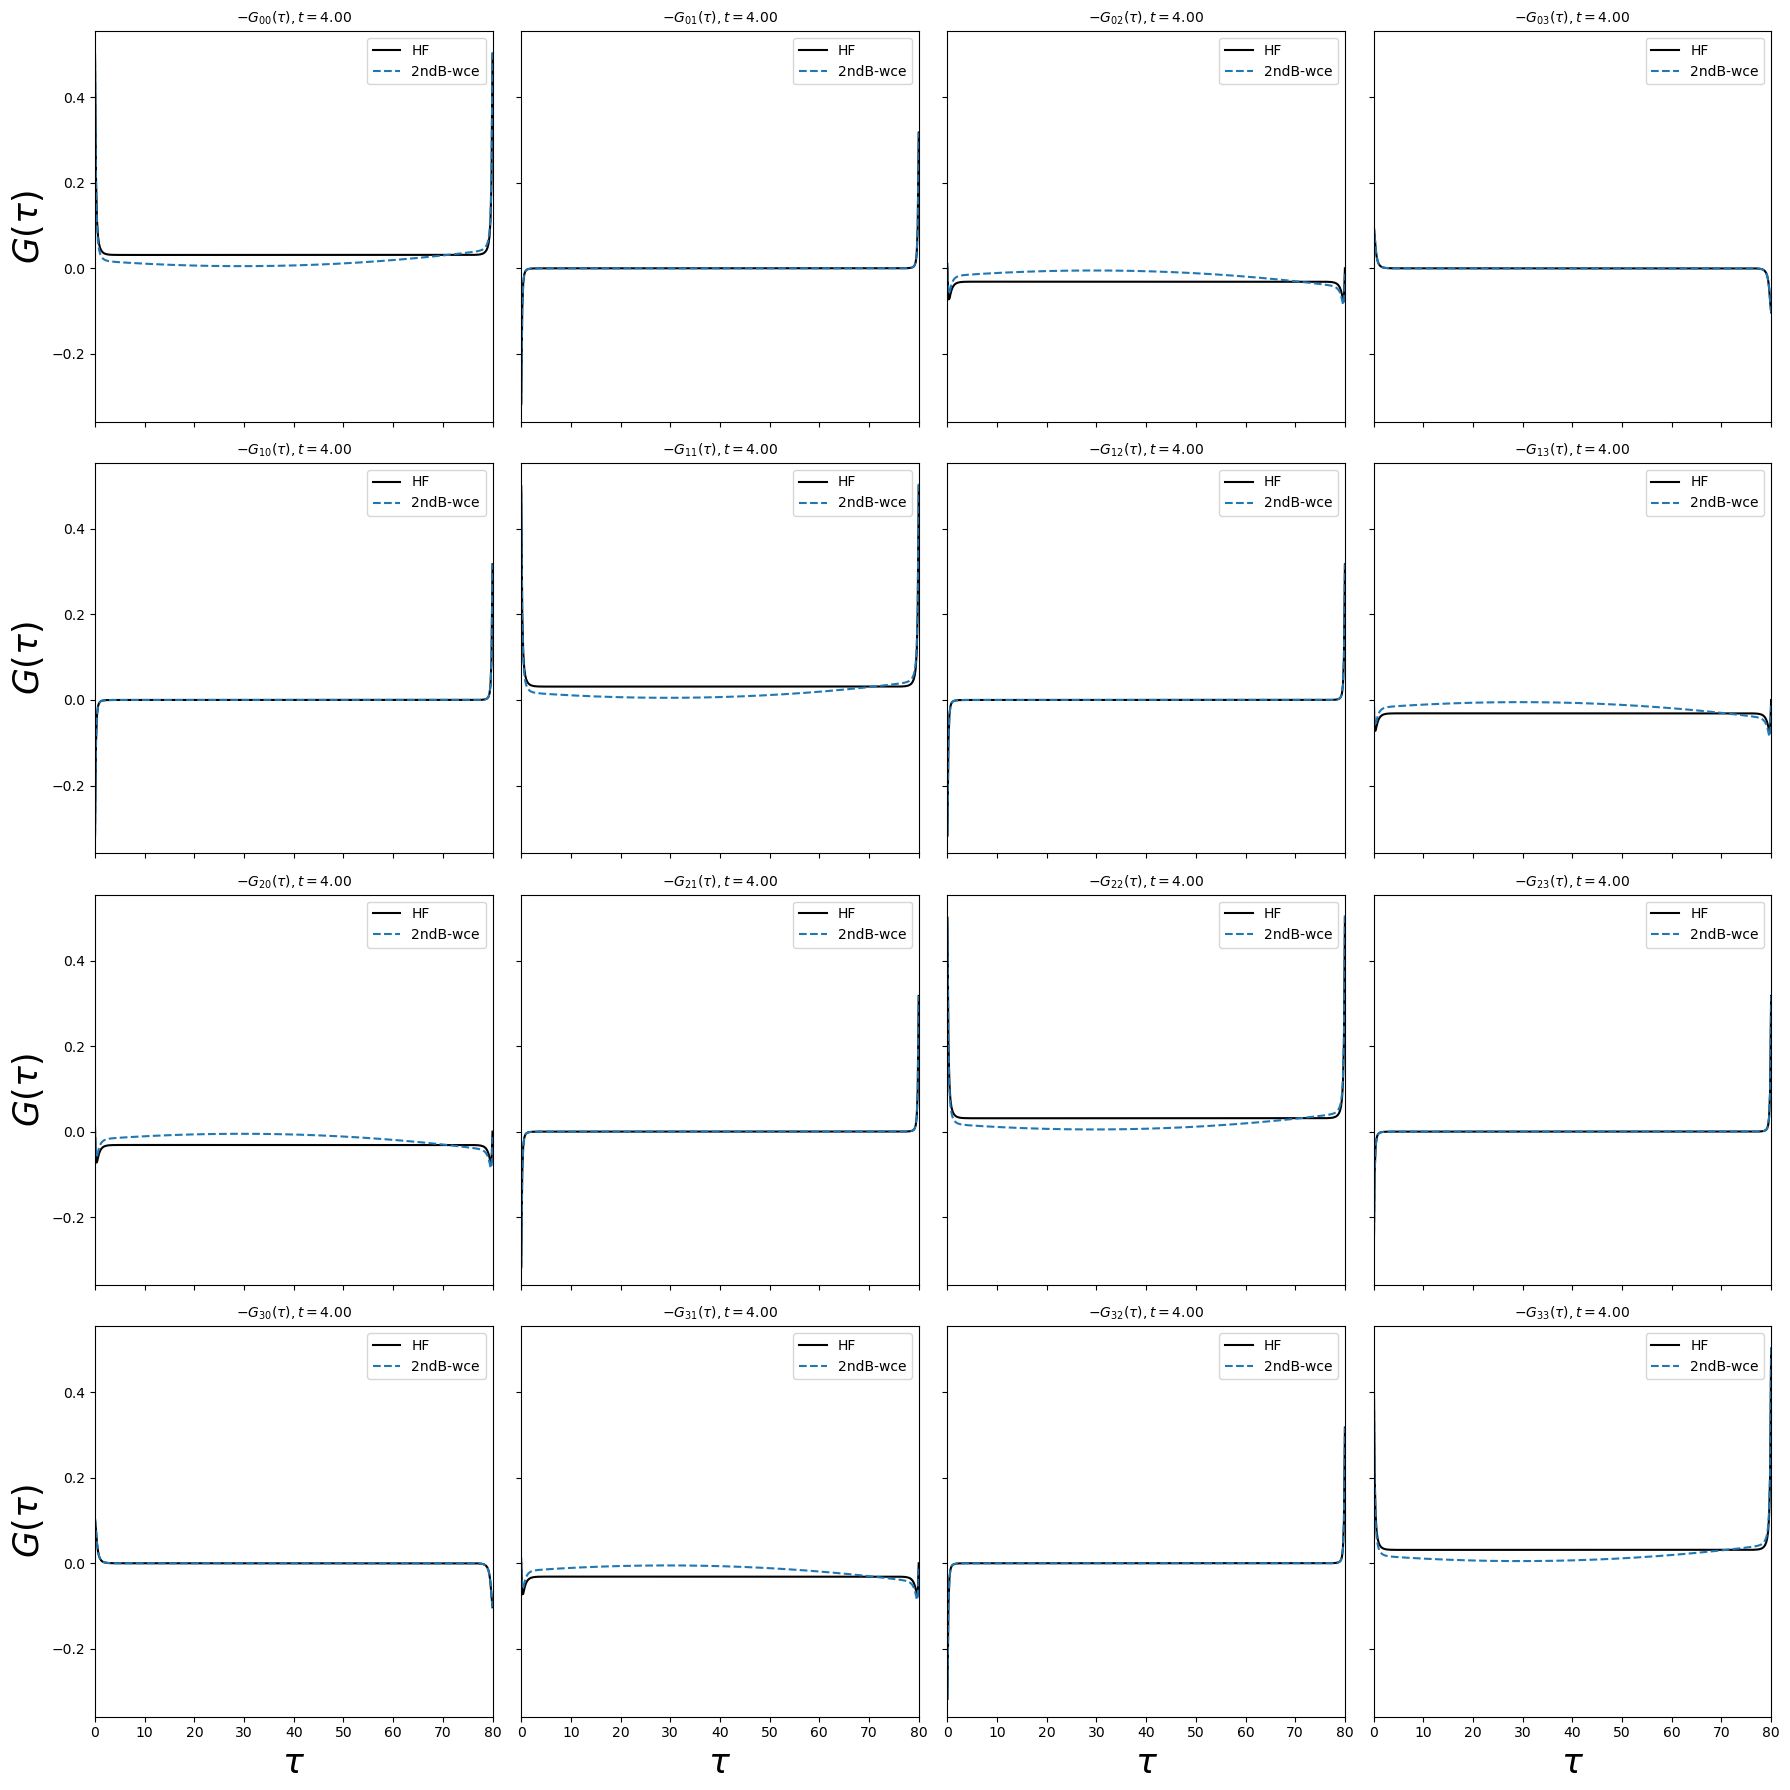

In [68]:
G0ij_tau = wce.Gij_iwn_to_Gij_tau(G0ij_iwn, wn, tau, beta)
# Gij_tau = wce.Gij_iwn_to_Gij_tau(Gij_iwn, wn, tau, beta)
Gij_tau_wce = wce.Gij_iwn_to_Gij_tau(Gij_iwn_wce, wn, tau, beta)

fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        ax.plot(tau, -G0ij_tau[:, i ,j ].real, 'k', label= 'HF')
        # ax.plot(tau, -Gij_tau[:, i ,j ].real, 'r--', label= '2ndB')
        ax.plot(tau, -Gij_tau_wce[:, i ,j ].real, 'C0--', label= '2ndB-wce')
        ax.set_title(r'$-G_{%d%d}(\tau), t=%.2f$'%(i,j, -t), fontsize=10)
        ax.tick_params(labelsize=10)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel(r"$\tau$", fontsize=25)
            ax.set_xlim([0, beta])
            # ax.set_ylim([-2,2])
        if j == 0:
            ax.set_ylabel(r"$G(\tau)$", fontsize=25)

plt.tight_layout()
plt.show()

In [ ]:
# Ns_plot = 4
# fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

# for i in range(Ns_plot):
#     for j in range(Ns_plot):
#         ax = axes[i, j]
#         if (-1)**(i+j) <0:
#             ax.plot(wn, Sij_iwn[:, i ,j ].real, 'r', label= '2ndB')
#         else:
#             ax.plot(wn, Sij_iwn[:, i ,j ].imag, 'r', label= '2ndB')
#         ax.set_title(r'$\Sigma_{%d%d}(i\omega_n), t=%.2f$'%(i,j,-t), fontsize=10)
#         ax.tick_params(labelsize=10)
#         ax.legend(frameon = False)
#         if i == Ns_plot - 1:
#             ax.set_xlabel(r"$\omega_n$", fontsize=25)
#             ax.set_xlim([-20,20])
#             ax.set_ylim([-2,2])
#         if j == 0:
#             ax.set_ylabel(r"$\Sigma(i\omega_n)$", fontsize=25)

# plt.tight_layout()
# plt.show()
